# Análisis de confort en la navegación

Comfort during navigation: According to [15], comfort or discomfort in navigation is related to
variations in the wheelchair’s acceleration. This is determined by averaging the second derivative
of the wheelchair’s velocity in each section.

[15] Fr´ed´eric Leishman, Vincent Monfort, Odile Horn, and Guy Bourhis. Driving assistance by deictic
control for a smart wheelchair: The assessment issue. IEEE Transactions on Human-Machine
Systems, 44(1):66–77, 2013.

PARECE QUE ESE ARTÍCULO NO ES (VERIFICAR)

Lo que busca este programa es, a partir de la lectura de los Hall, que se reciben cada intervalo de tiempo específico, se determina la velocidad de cada rueda, la velocidad lineal y angular, y se estiman sus segundas derivadas mediante filtro de Savitzky-Golay para reducir el ruido. 


De aquí hay que sacar también NED
+ The normalized effective distance (NED), which relates the optimal path (mp) to the real trajectory (rt), as shown in equation below (the NED is a good indicator for comparing the motions performed by the user to the optimal route);

$NED = \frac{rt}{mp}$

C:/Users/alber/Documents/GitHub/SillaSamu/Postprocessing/samuchair_bag/20260316_132752/20260316_132752_0_csv/left_wheel_steps.csv
     log_time_s  publish_time_s  data
0  1.773664e+09    1.773664e+09     0
1  1.773664e+09    1.773664e+09     0
2  1.773664e+09    1.773664e+09     0
3  1.773664e+09    1.773664e+09     0
4  1.773664e+09    1.773664e+09     0
     log_time_s  publish_time_s  data
0  1.773664e+09    1.773664e+09     0
1  1.773664e+09    1.773664e+09     0
2  1.773664e+09    1.773664e+09     0
3  1.773664e+09    1.773664e+09     0
4  1.773664e+09    1.773664e+09     0


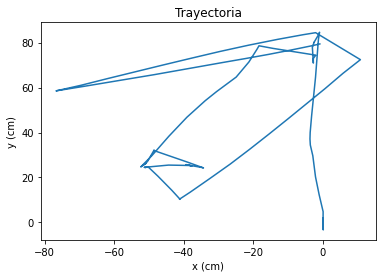

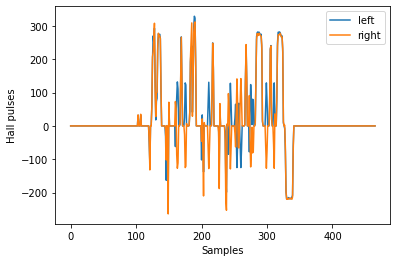

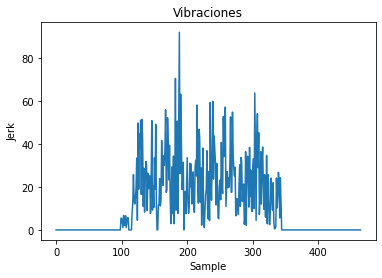

***********************
Longitud recorrida: 516.9391114647622 cm


In [6]:
import numpy as np
from scipy.signal import savgol_filter
import tkinter as tk
from tkinter import filedialog
import pandas as pd
import matplotlib.pyplot as plt



def calcular_aceleracion_y_jerk(velocidad, dt, window_length=7, polyorder=3):
    """
    Calcula la aceleración y su derivada (jerk) a partir de una serie temporal de 
    distancias recorridas entre muestras consecutivas, usando el filtro de Savitzky-Golay.

    Parámetros:
    -----------
    distancias : array-like
        Lista o array con las distancias recorridas entre cada muestra.
    dt : float
        Intervalo de muestreo en segundos.
    window_length : int, opcional
        Tamaño de la ventana para Savitzky-Golay (debe ser impar y > polyorder).
    polyorder : int, opcional
        Orden del polinomio usado en Savitzky-Golay.

    Retorna:
    --------
    aceleracion : np.ndarray
        Array con los valores de aceleración estimados (m/s^2).
    jerk : np.ndarray
        Array con los valores de la derivada de la aceleración (m/s^3).
    """
#    distancias = np.array(distancias)

    # Aceleración (1ª derivada de velocidad)
    #aceleracion = savgol_filter(velocidad, window_length, polyorder, deriv=1, delta=dt)

    # Jerk (derivada de la aceleración, es decir 2ª derivada de la velocidad)
    jerk = savgol_filter(velocidad, window_length, polyorder, deriv=2, delta=dt)

    #return aceleracion, jerk
    return jerk
'''  
def  calcula_jerk(data,dt=1):
    vl = (data[0,:]+data[1,:])/(2*dt)
    vg = (data[0,:]-data[1,:])/dt
    print(vl)
    print(vg)
    
    jerkl = calcular_aceleracion_y_jerk(vl,dt)
    jerkg = calcular_aceleracion_y_jerk(vg,dt)
    return jerkl,jerkg
# Intervalo de muestreo
'''


def representa_posicion(left,right):
    '''ESTO ES FALSO, HAY QUE SABER LA CONVERSIÓN
      Supongamos el plano (x,y). La coordenada y representa el avance.
      Los datos del hall representan, a falta de escala, el avance
       de la parte derecha e izquierda de la silla. La coordenada x
       se toma como la diferencia de ambas, mientras que la y el promedio
    '''
    Npulsos = 550  #Número de pulsos asociados a una vuelta completa
    R = 15.5   #Radio de la rueda en cm
    k = 2*np.pi*R  / Npulsos   #Constante de conversión de pulsos a cm 
    D = 55   #Distancia entre ruedas
    rt = 0   #Longitud recorrida en cm
    
    left_cm = left*k
    right_cm = right*k
    l = k*(left_cm+right_cm)/2
    rt = np.sum(np.abs(l))   #Es importante que sea en valor absoluto
    angulo = np.cumsum(np.arctan((-right_cm+left_cm)/D))  #Ajustar la constante
    dx=-l*np.sin(angulo)
    dy=l*np.cos(angulo)
    x,y = np.cumsum(dx),np.cumsum(dy)
    plt.plot(x,y)
    plt.title('Trayectoria')
    plt.xlabel('x (cm)')
    plt.ylabel('y (cm)')
    plt.show()
    
    plt.plot(left,label='left')
    plt.plot(right,label='right')
    plt.ylabel('Hall pulses')
    plt.xlabel('Samples')
    plt.legend()
    plt.show()
    
    return x,y,rt


def calcula_jerk(datal,datar,dtl,dtr):
    a=np.array(datal)
    b=np.array(datar)
    #a=np.ones(100)*100
    #b=np.ones(100)*200
    x,y,rt=representa_posicion(a,b)
    at=np.array(dtl)
    bt=np.array(dtr)
    dt=(np.diff(at)+np.diff(bt))/2
    #print(dt)
    #vl = (a[1:]+b[1:])/2*dt
    #vg = (a[1:]-b[1:])/dt
    vx = np.diff(a)/dt
    vy = np.diff(b)/dt
    t = np.mean(dt)
    jerkx=calcular_aceleracion_y_jerk(vx,t)
    jerky=calcular_aceleracion_y_jerk(vy,t)
    #jerkl = calcular_aceleracion_y_jerk(vl,t)
    #jerkg = calcular_aceleracion_y_jerk(vg,t)
    #jerk  = calcular_aceleracion_y_jerk(v,t)
    return np.sqrt(jerkx**2+jerky**2),rt
    #return jerkl,jerkg
    #print((a[1:]+b[1:])/2*dt)
    #return jerk

root = tk.Tk()
root.withdraw()

'''file_path = filedialog.askopenfilename(
    title="Selecciona el CSV",
    filetypes=[("CSV files", "*.csv")]
)

if file_path:
    df = pd.read_csv(file_path)
    df.head()
    print(df.head)
else:
    print("No se seleccionó ningún archivo")
'''  
    
folder_path = filedialog.askdirectory(title="Selecciona la carpeta raíz para buscar MCAPs")
if folder_path:
    file_r = folder_path +'/right_wheel_steps.csv'
    file_l = folder_path + '/left_wheel_steps.csv'
    print(file_l)
    df_r = pd.read_csv(file_r)
    df_l = pd.read_csv(file_l)
    print(df_r.head())
    print(df_l.head())
    jerk,rt=calcula_jerk(df_l['data'],df_r['data'],df_l['log_time_s'],df_r['log_time_s'])
    plt.plot(np.abs(jerk))
    plt.title('Vibraciones')
    plt.ylabel('Jerk')
    plt.xlabel('Sample')
    plt.show()
    
    print('***********************')
    print(f'Longitud recorrida: {rt} cm')
else:
    print("No se seleccionó ningún archivo")
    


In [ ]:
print((data[0,:]+data[1,:])/2)

In [ ]:
a=np.array([1,2,-3])
b=np.array([1,-2,-3])
at=np.array([1,2,3])
bt=np.array([1.01,2,2.95])
dt=(np.diff(at)+np.diff(bt))/2
print(dt)
print((a[1:]+b[1:])/2*dt)

In [ ]:
a=np.ones(200)
b=np.ones(200)*0.5
l = (a+b)/2
angulo = np.cumsum(np.arctan((b-a)/10))
dx=-l*np.sin(angulo)
dy=l*np.cos(angulo)
plt.plot(np.cumsum(dx),np.cumsum(dy))
plt.show()

In [ ]:
import zlib

def generar_id_int32(nombre):
    return zlib.adler32(nombre.encode('utf-8')) &0xfffffff

name = 'Alberto_Molina'
user_id = generar_id_int32(name)
print(f"ID para {name} es: {user_id}" )

In [ ]:
import numpy as np
p = 0.38
# 0.23  = p*t+ (1-p)*0.29
t = (2.34 - (1-p)*2.98)/p
print(t)

cps = 0.427
#cps = 1/2.98
print(1/cps)

print(1/(2*np.pi*np.sqrt(500e3*10e3*220e-9*10e-9)))

In [ ]:
print(300/800)

In [ ]:
print(2784/550 * 2*3.1416*15.5/100)
print(2832/550 * 2*3.1416*15.5/100)
print(2887/550 * 2*3.1416*15.5/100)